In [2]:
import Pkg
using Sunny, GLMakie, StaticArrays

In [3]:
units = Units(:meV, :angstrom);

In [ ]:
latvecs = lattice_vectors(7.3177, 7.3177, 17.534, 90, 90, 120)
cryst = Crystal(latvecs, [[0.5, 0, 0]], 166)
sys = System(cryst, [1 => Moment(s=5/2, g=1)], :dipole)
set_exchange!(sys, 1.0, Bond(1, 2, [0, 0, 0]))


In [5]:
display(view_crystal(sys))

GLMakie.Screen(...)

In [6]:
randomize_spins!(sys)
minimize_energy!(sys)
# plot_spins(sys; color=[S[3] for S in sys.dipoles], ndims=2)

Converged in 19 iterations

In [7]:
qs = [[0, 0, 0], [1/3, 1/3, 0], [1/2, 0, 0], [0, 0, 0]]
labels = ["Γ", "K", "M", "Γ"]
path = q_space_path(cryst, qs, 150; labels)

QPath (150 samples)
  Γ → K → M → Γ


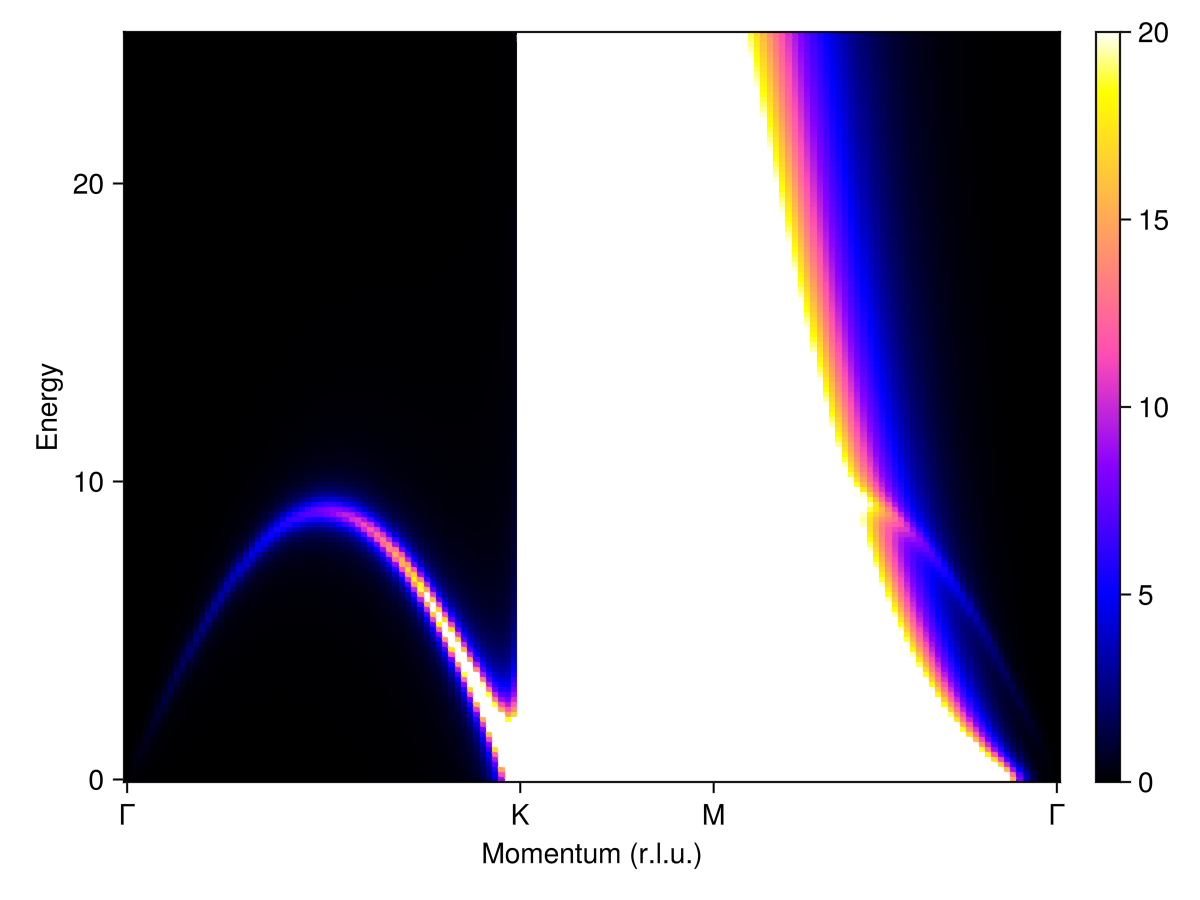

In [8]:
kernel = lorentzian(fwhm=0.8)
energies = range(0, 25, 150)
swt = SpinWaveTheory(sys; measure=ssf_perp(sys))
res = intensities(swt, path; energies, kernel)
plot_intensities(res, colorrange=(0, 20))

In [9]:
sys_inhom = to_inhomogeneous(repeat_periodically(sys, (20, 20, 1)))


System [Dipole mode]
Supercell (20×20×1)×9
Energy per site -45/4


In [10]:
for (site1, site2, offset) in symmetry_equivalent_bonds(sys_inhom, Bond(1, 1, [1, 0, 0]))
    noise = randn(sys_inhom.rng)/3
    set_exchange_at!(sys_inhom, 1.0 + noise, site1, site2; offset)
end

minimize_energy!(sys_inhom, maxiters=20000)
display(plot_spins(sys_inhom; color=[S[3] for S in sys_inhom.dipoles], ndims=2))

GLMakie.Screen(...)

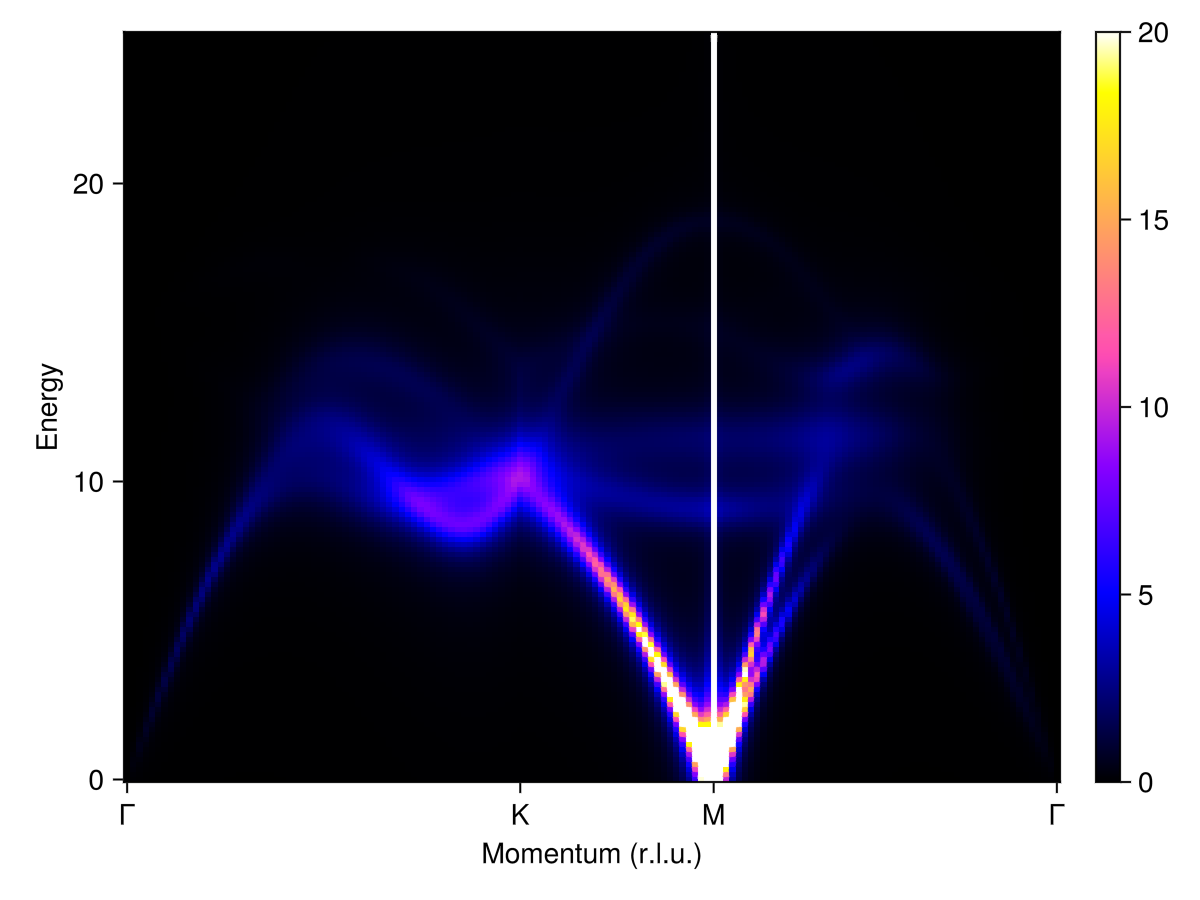

In [11]:
swt = SpinWaveTheoryKPM(sys_inhom; measure=ssf_perp(sys_inhom), tol=0.05)
res = intensities(swt, path; energies, kernel)
plot_intensities(res, colorrange = (0, 20))

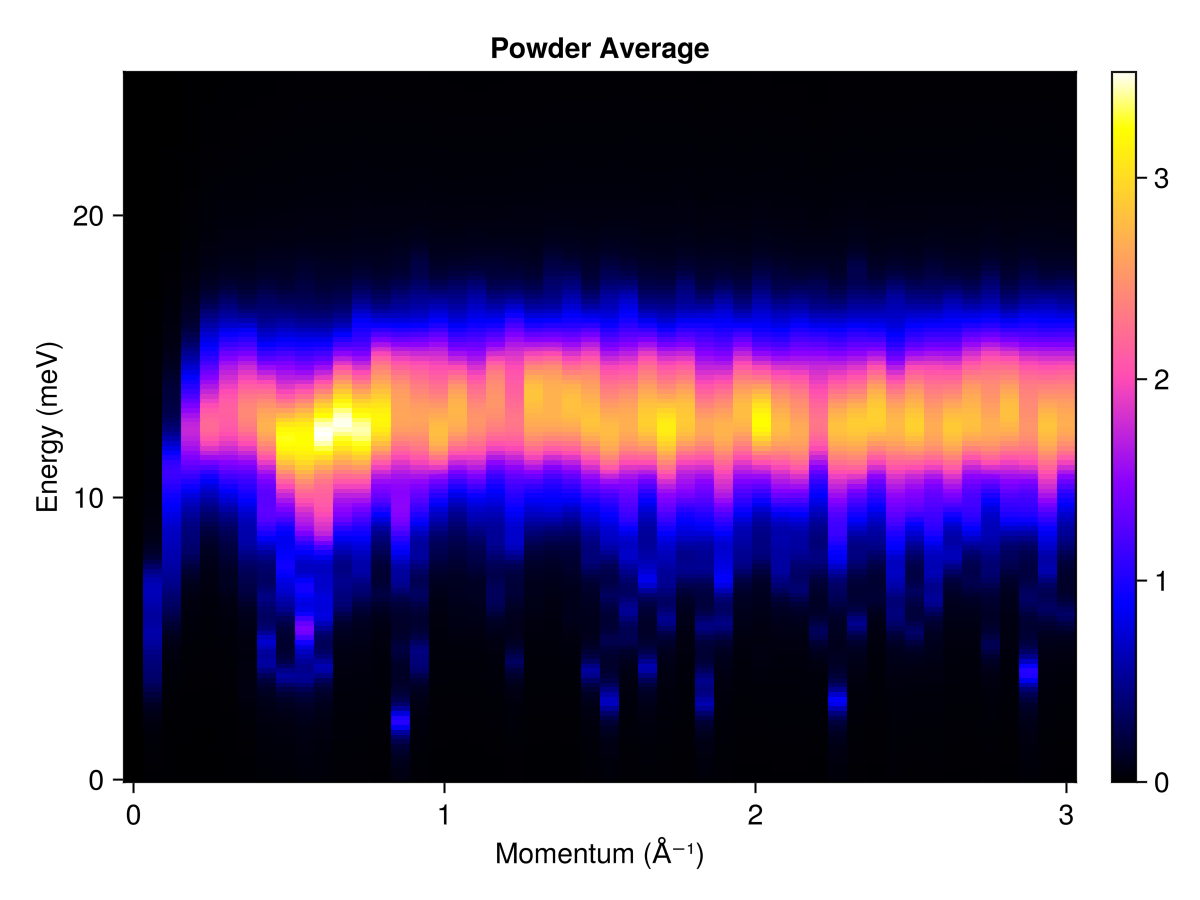

In [13]:
radii = range(0, 3, 50) # (1/Å)
res = powder_average(cryst, radii, 50) do qs
    intensities(swt, qs; energies, kernel)
end
plot_intensities(res; units, saturation=1.0, title="Powder Average")